# Kern Augmentation Manual Testing

Visual verification of kern augmentations by rendering before/after with Verovio.

In [ ]:
import sys

sys.path.insert(0, "..")

import verovio
from IPython.display import SVG, display

from scripts.dataset_generation.augmentation import apply_invisible_rests, apply_staccatos, apply_xtuplet
from scripts.dataset_generation.augmentation.kern_utils import find_note_tokens

In [3]:
# Sample kern for testing
SAMPLE_KERN = """**kern\t**kern
*clefF4\t*clefG2
*k[]\t*k[]
*M4/4\t*M4/4
4C\t4e 4g
4D\t4f 4a
4E\t4g 4b
4F\t4a 4cc
=\t=
2G\t2b 2dd
2A\t2cc 2ee
=\t=
*-\t*-"""

In [4]:
def render_kern(kern: str, scale: int = 40) -> SVG:
    """Render kern string to SVG using Verovio."""
    tk = verovio.toolkit()
    tk.setOptions({"scale": scale, "pageWidth": 1200, "adjustPageHeight": True})
    tk.loadData(kern)
    return SVG(tk.renderToSVG(1))


def show_diff(original: str, augmented: str) -> None:
    """Display kern diff highlighting added characters."""
    print("=== KERN DIFF ===")
    orig_lines = original.splitlines()
    aug_lines = augmented.splitlines()

    for i, (o, a) in enumerate(zip(orig_lines, aug_lines, strict=False)):
        if o != a:
            print(f"L{i}: {o!r}")
            print(f"  -> {a!r}")
    print()

## Staccatos

Staccato (`'`) indicates short, detached notes.

In [5]:
# Check how many notes are available
positions = find_note_tokens(SAMPLE_KERN)
print(f"Found {len(positions)} notes that can receive articulations")

Found 12 notes that can receive articulations


In [6]:
# Apply staccatos with 100% probability to see all of them
augmented = apply_staccatos(SAMPLE_KERN, per_note_probability=1.0)

show_diff(SAMPLE_KERN, augmented)

=== KERN DIFF ===
L4: '4C\t4e 4g'
  -> "4C'\t4e 4g'"
L5: '4D\t4f 4a'
  -> "4D'\t4f 4a'"
L6: '4E\t4g 4b'
  -> "4E'\t4g 4b'"
L7: '4F\t4a 4cc'
  -> "4F'\t4a 4cc'"
L9: '2G\t2b 2dd'
  -> "2G'\t2b 2dd'"
L10: '2A\t2cc 2ee'
  -> "2A'\t2cc 2ee'"



ORIGINAL:


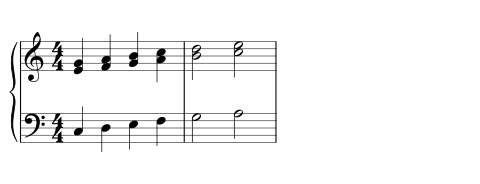

In [7]:
# Render original
print("ORIGINAL:")
display(render_kern(SAMPLE_KERN))

WITH STACCATOS:


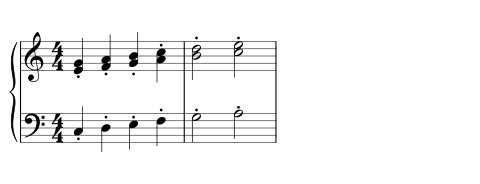

In [8]:
# Render augmented
print("WITH STACCATOS:")
display(render_kern(augmented))

WITH 30% STACCATO PROBABILITY:
=== KERN DIFF ===
L4: '4C\t4e 4g'
  -> "4C\t4e 4g'"
L6: '4E\t4g 4b'
  -> "4E'\t4g 4b"
L9: '2G\t2b 2dd'
  -> "2G\t2b 2dd'"
L10: '2A\t2cc 2ee'
  -> "2A'\t2cc 2ee"



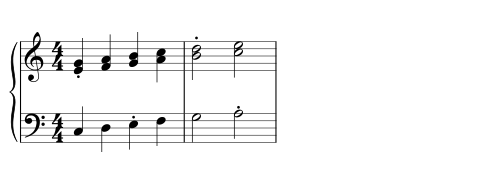

In [9]:
# Test with realistic probability
realistic = apply_staccatos(SAMPLE_KERN, per_note_probability=0.3)

print("WITH 30% STACCATO PROBABILITY:")
show_diff(SAMPLE_KERN, realistic)
display(render_kern(realistic))

## Xtuplet Markers

`*Xtuplet` marks spines that contain tuplet rhythms (non-power-of-2 values like triplets).

In [10]:
# Sample kern with tuplets (triplets in right hand)
TUPLET_KERN = """**kern	**kern
*clefF4	*clefG2
*k[b-e-a-d-]	*k[b-e-a-d-]
*	*^
4D- 4B--	12ryy	12g-L\\
.	6ee--/	12ee--\\
.	.	12g-J\\
4DD-	4ryy	12d-L
.	.	12g-
.	.	12d-J
!LO:S:b	*	*
4D- 4B--	12ryy	12g-L\\
.	6dd-/	12dd-\\
.	.	12d-J\\
=\t=\t=
*-\t*-\t*-"""

print("Sample kern with tuplets (triplets in spine 1):")
print(TUPLET_KERN)

Sample kern with tuplets (triplets in spine 1):
**kern	**kern
*clefF4	*clefG2
*k[b-e-a-d-]	*k[b-e-a-d-]
*	*^
4D- 4B--	12ryy	12g-L\
.	6ee--/	12ee--\
.	.	12g-J\
4DD-	4ryy	12d-L
.	.	12g-
.	.	12d-J
!LO:S:b	*	*
4D- 4B--	12ryy	12g-L\
.	6dd-/	12dd-\
.	.	12d-J\
=	=	=
*-	*-	*-


ORIGINAL (with triplets):


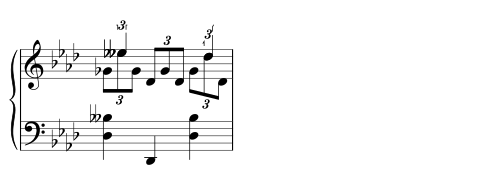

In [11]:
# Render original with tuplets
print("ORIGINAL (with triplets):")
display(render_kern(TUPLET_KERN))

In [12]:
# Apply xtuplet with 100% probability to see it
xtuplet_augmented = apply_xtuplet(TUPLET_KERN, per_spine_probability=1.0)

print("WITH *Xtuplet MARKER:")
print(xtuplet_augmented)
print()

WITH *Xtuplet MARKER:
**kern	**kern
*clefF4	*clefG2
*k[b-e-a-d-]	*k[b-e-a-d-]
*	*Xtuplet
*	*^
4D- 4B--	12ryy	12g-L\
.	6ee--/	12ee--\
.	.	12g-J\
4DD-	4ryy	12d-L
.	.	12g-
.	.	12d-J
!LO:S:b	*	*
4D- 4B--	12ryy	12g-L\
.	6dd-/	12dd-\
.	.	12d-J\
=	=	=
*-	*-	*-



AUGMENTED:


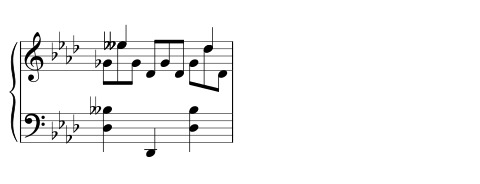

In [13]:
print("AUGMENTED:")
display(render_kern(xtuplet_augmented))

## Invisible Rests

`yy` marks rests as invisible in the render. In multi-voice music, rests are often hidden to reduce visual clutter when another voice has activity.

In [14]:
# Sample kern with multi-voice region (spine split)
MULTIVOICE_KERN = """**kern\t**kern
*clefF4\t*clefG2
*k[]\t*k[]
*M4/4\t*M4/4
4C\t4e
*\t*^
4D\t4f\t4r
4E\t4g\t4r
4F\t4a\t8r
.\t.\t8r
*\t*v\t*v
=\t=
2G\t2b
*-\t*-"""

print("Sample kern with multi-voice region (rests in voice 3):")
print(MULTIVOICE_KERN)

Sample kern with multi-voice region (rests in voice 3):
**kern	**kern
*clefF4	*clefG2
*k[]	*k[]
*M4/4	*M4/4
4C	4e
*	*^
4D	4f	4r
4E	4g	4r
4F	4a	8r
.	.	8r
*	*v	*v
=	=
2G	2b
*-	*-


ORIGINAL (rests visible in multi-voice region):


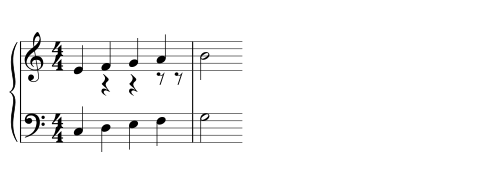

In [15]:
# Render original with visible rests
print("ORIGINAL (rests visible in multi-voice region):")
display(render_kern(MULTIVOICE_KERN))

In [16]:
# Apply invisible rests with 100% probability
invisible_augmented = apply_invisible_rests(MULTIVOICE_KERN, per_rest_probability=1.0)

print("WITH INVISIBLE RESTS (yy suffix):")
show_diff(MULTIVOICE_KERN, invisible_augmented)
print(invisible_augmented)

WITH INVISIBLE RESTS (yy suffix):
=== KERN DIFF ===
L6: '4D\t4f\t4r'
  -> '4D\t4f\t4ryy'
L7: '4E\t4g\t4r'
  -> '4E\t4g\t4ryy'
L8: '4F\t4a\t8r'
  -> '4F\t4a\t8ryy'
L9: '.\t.\t8r'
  -> '.\t.\t8ryy'

**kern	**kern
*clefF4	*clefG2
*k[]	*k[]
*M4/4	*M4/4
4C	4e
*	*^
4D	4f	4ryy
4E	4g	4ryy
4F	4a	8ryy
.	.	8ryy
*	*v	*v
=	=
2G	2b
*-	*-


AUGMENTED (rests now invisible):


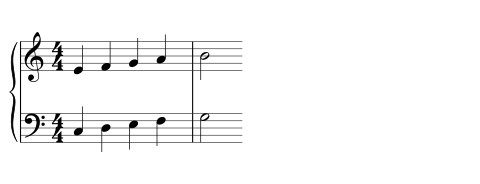

In [17]:
# Render augmented - rests should now be hidden
print("AUGMENTED (rests now invisible):")
display(render_kern(invisible_augmented))